In [1]:
#Importar librerias
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

## Considere los valores históricos del Producto Interno Bruto (GDP) para México de acuerdo a los registros del banco mundial.

In [3]:
#Traer la base de datos a utlizar
df = pd.read_excel("Mexico GDP.xlsx")
df.head()

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


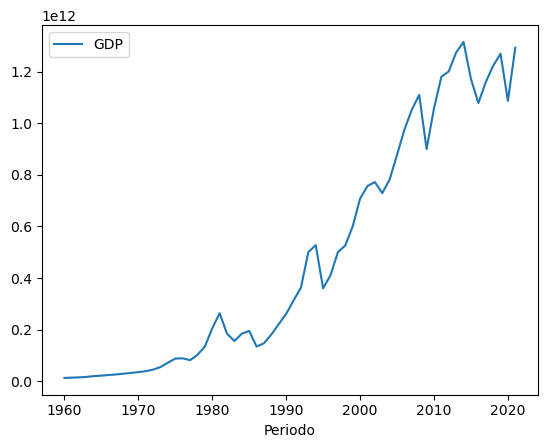

In [4]:
# Graficar la tabla para hacer una idea de los posible comportamientos que tendra
Base_Datos = df[["Periodo", "GDP"]]
GraficaB = Base_Datos.plot.line(x = "Periodo", y = "GDP")

## Mediante una regresión de mínimos cuadrados ajuste los datos del archivo anterior al modelo logístico siguiente:

<img src= "m19 2.png" width = "500" height = "340">

## donde X representa el período (año) y Y el PIB. De lo anterior es evidente que debe estimar dos parámetros (Beta1 y Beta2 ). 

### ¿Tuvo algún problema en el proceso de estimación de parámetros?
Debido a que aunque de manera MUY "generalizada" esta tiene mas un comportamiento sinusoidal
### ¿A qué crees que se debe? 
Pero hubo varios problemas dados que los problemas debido a que los metodos sinusoidales  o logisticos en este caso se utilizan mas en tipo "true or False" o "categoricos" no tanto en predicciones numericas.

No se muestra en el codigo pero estuve 2 horas peleandome con el codigo sin entender porque fallaba con variables no boleanas.

In [10]:
# Creacion de la muestra aleatoria
Mask = np.random.rand(len(Base_Datos)) <= 0.80
Entrenamiento = Base_Datos[Mask]
Prueba = Base_Datos[~Mask]

# DAtos de entrenamiento
train_x = np.asanyarray(Entrenamiento[["Periodo"]])
train_y = np.asanyarray(Entrenamiento[["GDP"]])

#Datos de prueba
Prueba_x = np.asanyarray(Prueba[["Periodo"]])
Prueba_y = np.asanyarray(Prueba[["GDP"]])

In [11]:
# Importar base de datos para regrecion lineal
from sklearn import linear_model
regr = linear_model.LinearRegression()
regr.fit(train_x, train_y)

#Obtener coeficientes de los datos
print("Coeficiente de pendiente", regr.coef_)
print("Coeficiente de intercept", regr.intercept_)

Coeficiente de pendiente [[2.30141381e+10]]
Coeficiente de intercept [-4.53288721e+13]


Text(0, 0.5, 'GDP')

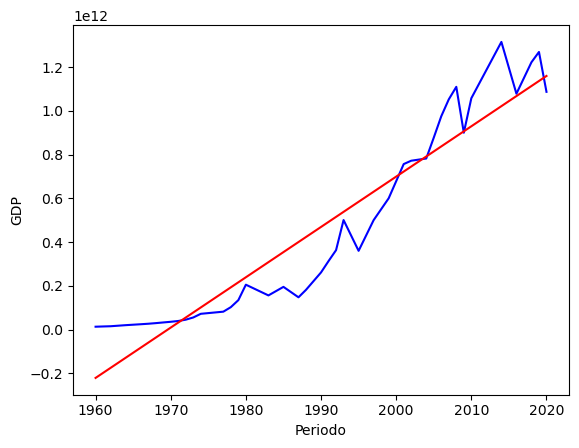

In [14]:
#Grafico para comparar los comportamientos de la grafica segun lo predicho
plt.plot(Entrenamiento.Periodo, Entrenamiento.GDP, "-b")
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], "-r")
plt.xlabel("Periodo")
plt.ylabel("GDP")

# Transforme la base de datos previa dividiendo cada observación entre el valor máximo de la columna a la que pertenece. A este proceso se le denomina “Normalización”.

In [17]:
#Normalizar los valores de la Base de Datos original
Norm_O = pd.Series(Base_Datos["GDP"] / Base_Datos["GDP"].max(), name="Normalizar_Orig")

#Normalizacion de las predicciones
Prediccion = regr.coef_[0][0]*np.asanyarray(Base_Datos[["Periodo"]]) + regr.intercept_[0]
Norm_P = pd.DataFrame(Prediccion/Prediccion.max(), columns=['Normalizar_Pred'])

# Concatenar las tablas
BD_N = pd.concat([Base_Datos, Norm_O, Norm_P], axis=1)
BD_N

,Periodo,GDP,Normalizar_Orig,Normalizar_Pred
0,1960,1.304000e+10,0.009914,-0.186997
1,1961,1.416000e+10,0.010765,-0.167538
2,1962,1.520000e+10,0.011556,-0.148079
3,1963,1.696000e+10,0.012894,-0.128620
4,1964,2.008000e+10,0.015266,-0.109161
...,...,...,...,...
57,2017,1.158913e+12,0.881067,0.922164
58,2018,1.222408e+12,0.929340,0.941623
59,2019,1.269404e+12,0.965069,0.961082
60,2020,1.087118e+12,0.826485,0.980541


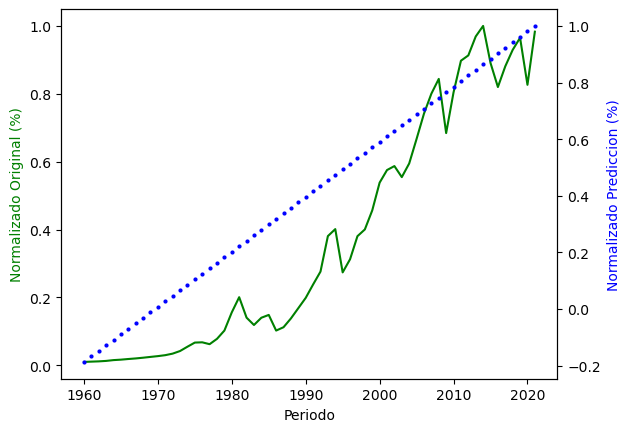

In [18]:
#Graficacion para comparar porcentualmente cuanta diferencia visulamente hay entre normlaizadores

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(BD_N["Periodo"], BD_N["Normalizar_Orig"], 'g-')
ax2.plot(BD_N["Periodo"], BD_N["Normalizar_Pred"], 'bo' , markersize=2)

ax1.set_xlabel('Periodo')
ax1.set_ylabel('Normalizado Original (%)', color='g')
ax2.set_ylabel('Normalizado Prediccion (%)', color='b')

plt.show()

In [19]:
print("Coeficiente de pendiente", regr.coef_)
print("Coeficiente de intercept", regr.intercept_)

Coeficiente de pendiente [[2.30141381e+10]]
Coeficiente de intercept [-4.53288721e+13]


## Formula:
### y = x*Coeficiente de pendiente + Intercepto

In [23]:
Y_MUESTRA = regr.predict(Prueba_x)

In [25]:
# Obtencion de datos para ver numericamente su fiabilidad
print("Mean absolute error: %.2f" % np.mean(np.absolute(Y_MUESTRA-Prueba_y))) #Error absoluto
print("Residual sum of squares (MSE): %.2f"% np.mean((Y_MUESTRA-Prueba_y) ** 2)) # Sume errores al cuadrado promedio
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(Y_MUESTRA, Prueba_y) )

Mean absolute error: 122239934283.88
Residual sum of squares (MSE): 21553533203205339480064.00
R2-score: 0.87


## Vuelva a intentar el ajuste del problema anterior para las dos nuevas columnas resultantes. 

### ¿Obtuvo resultados satisfactorios en esta ocasión?
Relativamente satisfactorio pero al ser un valor economico, estos valores tienden a comportarse mas como un logaritmo, logistico o sinusoidales.

### Explique a detalle comentando sobre la bonda de ajuste. 
Aunque la R**2 nos dio un 85% es casi seguro que con el paso del tiempo el error no hara mas que incrementar, ademas de que no evalua si esta tiene residuos sesgados.

### ¿Cuál sería su pronóstico del PIB (GDP) para México en el 2022? 
(Puede cambiar si vuelve a alterarse los valores de prueba)
 Segun el modelo actual es de:

In [31]:
regr.predict([[2022]])

array([[1.20571518e+12]])

### ¿Qué mecanismo de transformación tendría que realizar en dicho caso?

Los que recomendaria para este caso segun el comportamiento de la tabla seria lo mas recomendable utilizar comandos como:
"scipy.optimize.curve_fit", pero por parte del metodo la Discrezitacion seria un buen punto para poder usar las funciones logisticas, unicamente que dejaria un rango muy grande de errores e intretaciones al tener que delimitar cierta catergoria segun el GPD. Entonces lo que YO recomendaria seria utilizar el metodo de agregacion, dado que aunque no te dara valores especificos al año, puede delimitar "un rango de periodos"